# Classificação da Qualidade de Vinhos com Machine Learning

## Objetivo

O objetivo deste projeto é desenvolver modelos de classificação capazes de
prever se um vinho pertence à categoria de alta qualidade ou de baixa/média
qualidade, utilizando suas características físico-químicas.

A variável original `quality` foi transformada em uma classificação binária:

- **Alta Qualidade:** nota maior ou igual a 7;
- **Baixa/Média Qualidade:** nota menor que 7.

Serão realizadas a análise exploratória, a preparação dos dados, o treinamento
de dois modelos e a comparação de seus resultados.

#1) Balanceamento do alvo

In [ ]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Configuração de caminhos compatível com GitHub/local e Google Colab
caminhos_dados = [
    Path("../data/WineQT.csv"),  # execução a partir de notebooks/
    Path("data/WineQT.csv"),     # execução a partir da raiz do repositório
    Path("/content/WineQT.csv")  # Google Colab com upload direto
]

DATA_PATH = next((caminho for caminho in caminhos_dados if caminho.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Arquivo WineQT.csv não encontrado. "
        "No repositório, mantenha-o em data/WineQT.csv. "
        "No Google Colab, faça o upload para /content/WineQT.csv."
    )

if str(DATA_PATH) == "../data/WineQT.csv":
    RESULTS_DIR = Path("../results")
elif str(DATA_PATH) == "data/WineQT.csv":
    RESULTS_DIR = Path("results")
else:
    RESULTS_DIR = Path("/content/results")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
total_registros = len(df)

print(f"Dataset carregado de: {DATA_PATH}")
print(f"Pasta de resultados: {RESULTS_DIR}")
print(f"Total de registros na base: {total_registros}")


In [2]:
# 3. variável de classificação binária
# Regra do desafio:
# quality >= 7  -> Alta Qualidade
# quality < 7   -> Baixa/Média Qualidade

df["classe_qualidade"] = np.where(
    df["quality"] >= 7,
    "Alta Qualidade",
    "Baixa/Média Qualidade"
)

In [3]:
# 4. Count qtd de vinhos em cada classe
qtd_classes = df["classe_qualidade"].value_counts()

# 5. Calc % de cada classe
perc_classes = df["classe_qualidade"].value_counts(normalize=True) * 100

# 6. resumo
balanceamento = pd.DataFrame({
    "Quantidade": qtd_classes,
    "Percentual": perc_classes.round(1)
})

balanceamento

,Quantidade,Percentual
classe_qualidade,,
Baixa/Média Qualidade,984,86.1
Alta Qualidade,159,13.9


In [4]:
# 7. especificamente o percentual de vinhos de alta qualidade
perc_alta_qualidade = balanceamento.loc["Alta Qualidade", "Percentual"]
qtd_alta_qualidade = balanceamento.loc["Alta Qualidade", "Quantidade"]

print(
    f"Apenas {perc_alta_qualidade}% dos vinhos são de alta qualidade "
    f"({qtd_alta_qualidade} registros de {total_registros})."
)

Apenas 13.9% dos vinhos são de alta qualidade (159 registros de 1143).


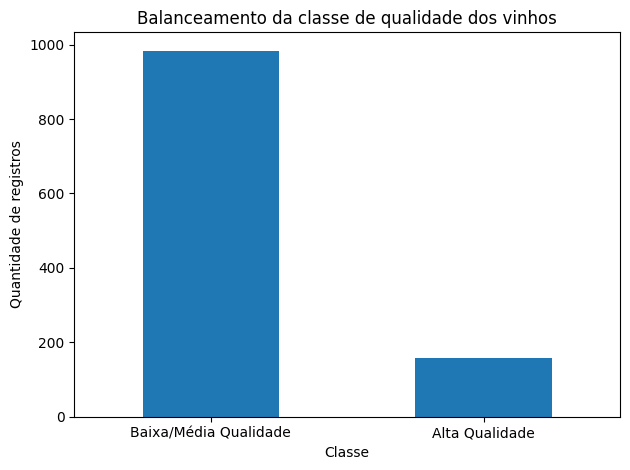

In [46]:
# 8 gráfico
import matplotlib.pyplot as plt

balanceamento["Quantidade"].plot(kind="bar")

plt.title("Balanceamento da classe de qualidade dos vinhos")
plt.xlabel("Classe")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=0)

# Ajusta o layout para evitar cortes no título e nos rótulos
plt.tight_layout()

# Salva o gráfico na pasta results
plt.savefig(
    f"{RESULTS_DIR}/distribuicao_classes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#2) Distribuição das notas

In [6]:
# 1. qtd de registros por nota de qualidade
qtd_por_nota = df["quality"].value_counts().sort_index()

qtd_por_nota

,count
quality,
3,6
4,33
5,483
6,462
7,143
8,16


In [7]:
# 2. % de cada nota
perc_por_nota = (df["quality"].value_counts(normalize=True).sort_index() * 100).round(1)

perc_por_nota

,proportion
quality,
3,0.5
4,2.9
5,42.3
6,40.4
7,12.5
8,1.4


In [8]:
# 3. resumo
distribuicao_quality = pd.DataFrame({
    "Quantidade": qtd_por_nota,
    "Percentual": perc_por_nota
})

distribuicao_quality

,Quantidade,Percentual
quality,,
3,6,0.5
4,33,2.9
5,483,42.3
6,462,40.4
7,143,12.5
8,16,1.4


In [9]:
# 3.5 Calculando as variáveis primeiro
qtd_notas_5_6 = df['quality'].isin([5, 6]).sum()
total_registros = len(df)
perc_notas_5_6 = (qtd_notas_5_6 / total_registros) * 100
perc_fora_5_6 = 100 - perc_notas_5_6

# 4. Exibindo a qtd e % das notas intermediárias 5 e 6, e os registros fora dessa faixa
print(
    f"As notas 5 e 6 concentram {qtd_notas_5_6} registros, "
    f"o que representa {perc_notas_5_6:.1f}% da base. "
    f"Isso mostra que a qualidade está concentrada em notas intermediárias, "
    f"com apenas {perc_fora_5_6:.1f}% dos registros fora dessa faixa."
)

As notas 5 e 6 concentram 945 registros, o que representa 82.7% da base. Isso mostra que a qualidade está concentrada em notas intermediárias, com apenas 17.3% dos registros fora dessa faixa.


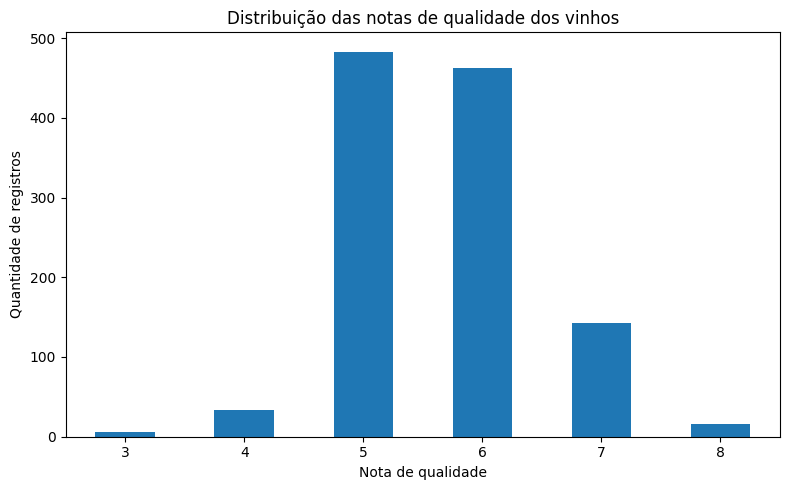

In [47]:
# 5. Gráfico da distribuição das notas de qualidade

plt.figure(figsize=(8, 5))

distribuicao_quality["Quantidade"].plot(kind="bar")

plt.title("Distribuição das notas de qualidade dos vinhos")
plt.xlabel("Nota de qualidade")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_DIR}/distribuicao_qualidade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#3) Correlação positiva

In [11]:
# 1. primeiras linhas
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,classe_qualidade
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,Baixa/Média Qualidade
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,Baixa/Média Qualidade
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,Baixa/Média Qualidade
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,Baixa/Média Qualidade
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,Baixa/Média Qualidade


In [12]:
# 2. Remover a coluna Id, é apenas um identificador
df_corr = df.drop(columns=["Id"])

# 3. Calcular a correlação das variáveis com a qualidade
correlacoes_quality = df_corr.corr(numeric_only=True)["quality"].drop("quality")

# 4. Ordenar da maior correlação positiva para a menor
correlacoes_quality = correlacoes_quality.sort_values(ascending=False)

correlacoes_quality

,quality
alcohol,0.484866
sulphates,0.257710
citric acid,0.240821
fixed acidity,0.121970
residual sugar,0.022002
pH,-0.052453
free sulfur dioxide,-0.063260
chlorides,-0.124085
density,-0.175208
total sulfur dioxide,-0.183339


In [13]:
# 5. tabela
tabela_correlacoes = pd.DataFrame({
    "Variável": correlacoes_quality.index,
    "Correlação com quality": correlacoes_quality.values
})

# 6. arredondar 3 casas decimais
tabela_correlacoes["Correlação com quality"] = tabela_correlacoes["Correlação com quality"].round(3)

tabela_correlacoes

,Variável,Correlação com quality
0,alcohol,0.485
1,sulphates,0.258
2,citric acid,0.241
3,fixed acidity,0.122
4,residual sugar,0.022
5,pH,-0.052
6,free sulfur dioxide,-0.063
7,chlorides,-0.124
8,density,-0.175
9,total sulfur dioxide,-0.183


In [14]:
# 7. apenas correlações positivas
correlacoes_positivas = correlacoes_quality[correlacoes_quality > 0]

# 8. variável com maior correlação positiva
principal_variavel_positiva = correlacoes_positivas.idxmax()
maior_correlacao_positiva = correlacoes_positivas.max()

print(f"Principal indicador positivo: {principal_variavel_positiva}")
print(f"Correlação com quality: {maior_correlacao_positiva:.3f}")

Principal indicador positivo: alcohol
Correlação com quality: 0.485


In [15]:
# 9. Gerar síntese do principal indicador positivo
print(
    f"O teor alcoólico é o principal indicador positivo, "
    f"com correlação de +{maior_correlacao_positiva:.3f} com a qualidade."
)

O teor alcoólico é o principal indicador positivo, com correlação de +0.485 com a qualidade.


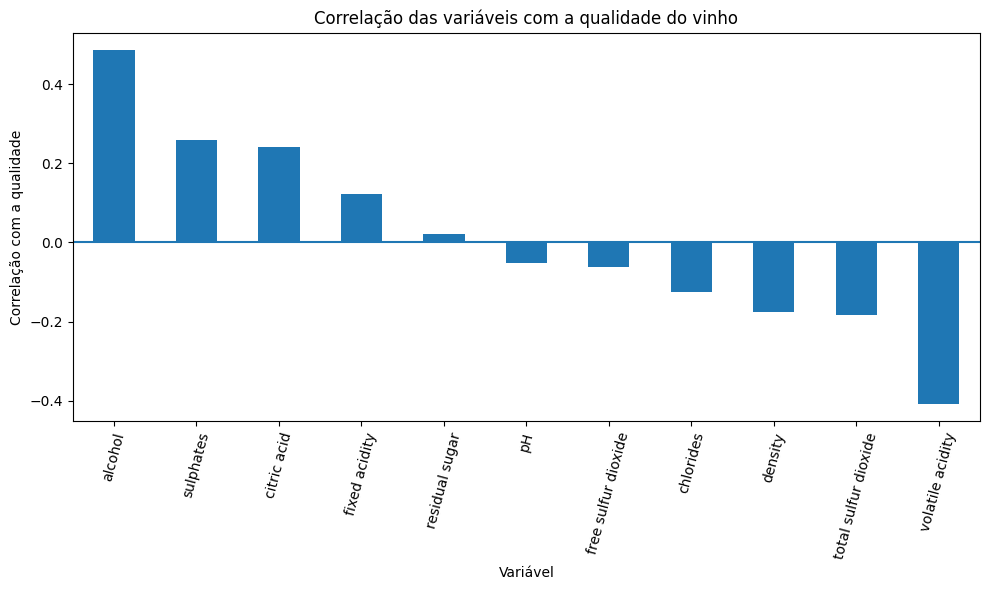

In [49]:
# 10. Gráfico das correlações com a qualidade
tabela_correlacoes_plot = tabela_correlacoes.set_index("Variável")

plt.figure(figsize=(10, 6))

tabela_correlacoes_plot["Correlação com quality"].plot(kind="bar")

plt.title("Correlação das variáveis com a qualidade do vinho")
plt.xlabel("Variável")
plt.ylabel("Correlação com a qualidade")
plt.xticks(rotation=75)
plt.axhline(0)

plt.tight_layout()

plt.savefig(
    f"{RESULTS_DIR}/correlacoes_com_qualidade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#4) Correlação negativa

In [17]:
# 1. Remover a coluna Id
df_corr = df.drop(columns=["Id"])

# 2. Calcular a correlação das variáveis com a qualidade
correlacoes_quality = df_corr.corr(numeric_only=True)["quality"].drop("quality")

# 3. ordena correlação mais negativa para a mais positiva
correlacoes_quality_negativas = correlacoes_quality.sort_values(ascending=True)

correlacoes_quality_negativas

,quality
volatile acidity,-0.407394
total sulfur dioxide,-0.183339
density,-0.175208
chlorides,-0.124085
free sulfur dioxide,-0.063260
pH,-0.052453
residual sugar,0.022002
fixed acidity,0.121970
citric acid,0.240821
sulphates,0.257710


In [18]:
# 4. Filtrar apenas negativas
correlacoes_negativas = correlacoes_quality[correlacoes_quality < 0]

# 5. variável com a correlação mais negativa
principal_variavel_negativa = correlacoes_negativas.idxmin()
maior_correlacao_negativa = correlacoes_negativas.min()

print(f"Principal indicador negativo: {principal_variavel_negativa}")
print(f"Correlação com quality: {maior_correlacao_negativa:.3f}")

Principal indicador negativo: volatile acidity
Correlação com quality: -0.407


In [19]:
# 6. tabela apenas com correlações negativas
tabela_correlacoes_negativas = pd.DataFrame({
    "Variável": correlacoes_negativas.sort_values().index,
    "Correlação com quality": correlacoes_negativas.sort_values().values
})

# 7. Arredondar para 3 casas decimais
tabela_correlacoes_negativas["Correlação com quality"] = (
    tabela_correlacoes_negativas["Correlação com quality"].round(3)
)

tabela_correlacoes_negativas

,Variável,Correlação com quality
0,volatile acidity,-0.407
1,total sulfur dioxide,-0.183
2,density,-0.175
3,chlorides,-0.124
4,free sulfur dioxide,-0.063
5,pH,-0.052


In [20]:
#8 frase
print(
    f"A acidez volátil é o principal indicador negativo, "
    f"com correlação de {maior_correlacao_negativa:.3f} com a qualidade."
)

A acidez volátil é o principal indicador negativo, com correlação de -0.407 com a qualidade.


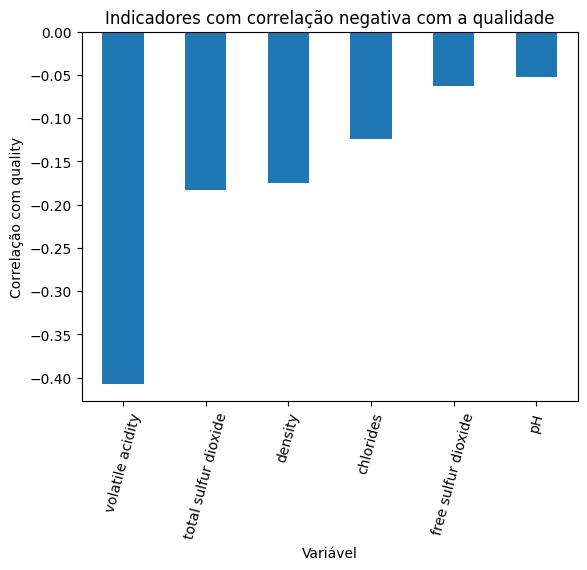

In [21]:
# 9. Gráfico apenas das correlações negativas
tabela_correlacoes_negativas.set_index("Variável")["Correlação com quality"].plot(kind="bar")

plt.title("Indicadores com correlação negativa com a qualidade")
plt.xlabel("Variável")
plt.ylabel("Correlação com quality")
plt.xticks(rotation=75)
plt.axhline(0)
plt.show()

#5) Registros duplicados

In [22]:
# 1. tamanho da base
print(f"Total de registros: {len(df)}")
qtd_colunas_originais = len([
    coluna for coluna in df.columns
    if coluna not in ["classe_qualidade", "target"]
])

print(f"Total de colunas da base original: {qtd_colunas_originais}")
print(f"Total de colunas após a criação da classe auxiliar: {df.shape[1]}")

Total de registros: 1143
Total de colunas da base original: 13
Total de colunas após a criação da classe auxiliar: 14


In [23]:
# 2. duplicatas considerando todas as colunas, incluindo id
duplicatas_com_id = df.duplicated().sum()

print(f"Duplicatas considerando todas as colunas, incluindo Id: {duplicatas_com_id}")

Duplicatas considerando todas as colunas, incluindo Id: 0


In [24]:
# 3. colunas que serão usadas para verificar duplicidade sem considerar o id
colunas_sem_id = [coluna for coluna in df.columns if coluna != "Id"]

# 4. duplicatas desconsiderando o Id
duplicatas_sem_id = df.duplicated(subset=colunas_sem_id).sum()

print(f"Duplicatas desconsiderando o Id: {duplicatas_sem_id}")

Duplicatas desconsiderando o Id: 125


In [25]:
# 5. % de duplicatas sem considerar o id
percentual_duplicatas_sem_id = (duplicatas_sem_id / len(df)) * 100

print(f"Percentual de duplicatas sem considerar o Id: {percentual_duplicatas_sem_id:.1f}%")

Percentual de duplicatas sem considerar o Id: 10.9%


In [26]:
# 6. todos os registros que possuem duplicidade sem considerar o id
registros_duplicados_sem_id = df[
    df.duplicated(subset=colunas_sem_id, keep=False)
].sort_values(by=colunas_sem_id)

registros_duplicados_sem_id

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,classe_qualidade
96,5.2,0.340,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6,142,Baixa/Média Qualidade
98,5.2,0.340,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6,144,Baixa/Média Qualidade
949,6.0,0.500,0.00,1.4,0.057,15.0,26.0,0.99448,3.36,0.45,9.5,5,1336,Baixa/Média Qualidade
950,6.0,0.500,0.00,1.4,0.057,15.0,26.0,0.99448,3.36,0.45,9.5,5,1337,Baixa/Média Qualidade
951,6.0,0.500,0.00,1.4,0.057,15.0,26.0,0.99448,3.36,0.45,9.5,5,1338,Baixa/Média Qualidade
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,12.8,0.615,0.66,5.8,0.083,7.0,42.0,1.00220,3.07,0.73,10.0,7,366,Alta Qualidade
400,13.0,0.470,0.49,4.3,0.085,6.0,47.0,1.00210,3.30,0.68,12.7,6,559,Baixa/Média Qualidade
404,13.0,0.470,0.49,4.3,0.085,6.0,47.0,1.00210,3.30,0.68,12.7,6,564,Baixa/Média Qualidade
170,15.0,0.210,0.44,2.2,0.075,10.0,24.0,1.00005,3.07,0.84,9.2,7,243,Alta Qualidade


In [27]:
# 7. Agrupar os registros iguais sem considerar o id
grupos_duplicados = (
    df.groupby(colunas_sem_id)
      .size()
      .reset_index(name="Quantidade")
      .query("Quantidade > 1")
      .sort_values(by="Quantidade", ascending=False)
)

grupos_duplicados

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,classe_qualidade,Quantidade
137,6.7,0.460,0.24,1.7,0.077,18.0,34.0,0.99480,3.39,0.60,10.6,6,Baixa/Média Qualidade,4
375,7.5,0.510,0.02,1.7,0.084,13.0,31.0,0.99538,3.36,0.54,10.5,6,Baixa/Média Qualidade,4
230,7.0,0.690,0.07,2.5,0.091,15.0,21.0,0.99572,3.38,0.60,11.3,6,Baixa/Média Qualidade,3
301,7.2,0.695,0.13,2.0,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5,Baixa/Média Qualidade,3
274,7.2,0.360,0.46,2.1,0.074,24.0,44.0,0.99534,3.40,0.85,11.0,7,Alta Qualidade,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,12.7,0.600,0.49,2.8,0.075,5.0,19.0,0.99940,3.14,0.57,11.4,5,Baixa/Média Qualidade,2
998,12.8,0.300,0.74,2.6,0.095,9.0,28.0,0.99940,3.20,0.77,10.8,7,Alta Qualidade,2
999,12.8,0.615,0.66,5.8,0.083,7.0,42.0,1.00220,3.07,0.73,10.0,7,Alta Qualidade,2
1004,13.0,0.470,0.49,4.3,0.085,6.0,47.0,1.00210,3.30,0.68,12.7,6,Baixa/Média Qualidade,2


In [28]:
# 8. qtd de linhas envolvidas em grupos duplicados
total_linhas_em_grupos_duplicados = len(registros_duplicados_sem_id)

print(f"Linhas envolvidas em grupos duplicados: {total_linhas_em_grupos_duplicados}")
print(f"Duplicatas além da primeira ocorrência: {duplicatas_sem_id}")

Linhas envolvidas em grupos duplicados: 239
Duplicatas além da primeira ocorrência: 125


In [29]:
# 9. qtd de grupos duplicados
qtd_grupos_duplicados = len(grupos_duplicados)

print(f"Quantidade de grupos duplicados sem considerar o Id: {qtd_grupos_duplicados}")

Quantidade de grupos duplicados sem considerar o Id: 114


In [30]:
# 10. Síntese da análise de registros duplicados
print(
    "A coluna Id é apenas um identificador. Ao removê-la da verificação, "
    f"foram encontrados {duplicatas_sem_id} registros duplicados. "
    "Isso precisa ser avaliado antes da separação entre treino e teste, "
    "pois registros iguais podem cair em bases diferentes e inflar o desempenho do modelo."
)

A coluna Id é apenas um identificador. Ao removê-la da verificação, foram encontrados 125 registros duplicados. Isso precisa ser avaliado antes da separação entre treino e teste, pois registros iguais podem cair em bases diferentes e inflar o desempenho do modelo.


### Decisão sobre os registros repetidos

Foram identificadas 125 repetições além da primeira ocorrência quando a
coluna `Id` foi desconsiderada.

Para a modelagem, esses registros foram removidos antes da divisão entre
treinamento e teste, evitando que amostras com características físico-químicas
idênticas fossem distribuídas entre os dois conjuntos e pudessem superestimar
o desempenho dos modelos.

Essa remoção representa uma decisão metodológica adotada no projeto. A
igualdade entre os registros não comprova, por si só, que as observações sejam
erros da base.

#6) Complemento da EDA

In [31]:
#Dados Ausentes
print("--- VERIFICAÇÃO DE DADOS AUSENTES ---")

dados_ausentes = df.isnull().sum()

print(dados_ausentes)
print(f"\nTotal de valores ausentes: {dados_ausentes.sum()}")

--- VERIFICAÇÃO DE DADOS AUSENTES ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
classe_qualidade        0
dtype: int64

Total de valores ausentes: 0


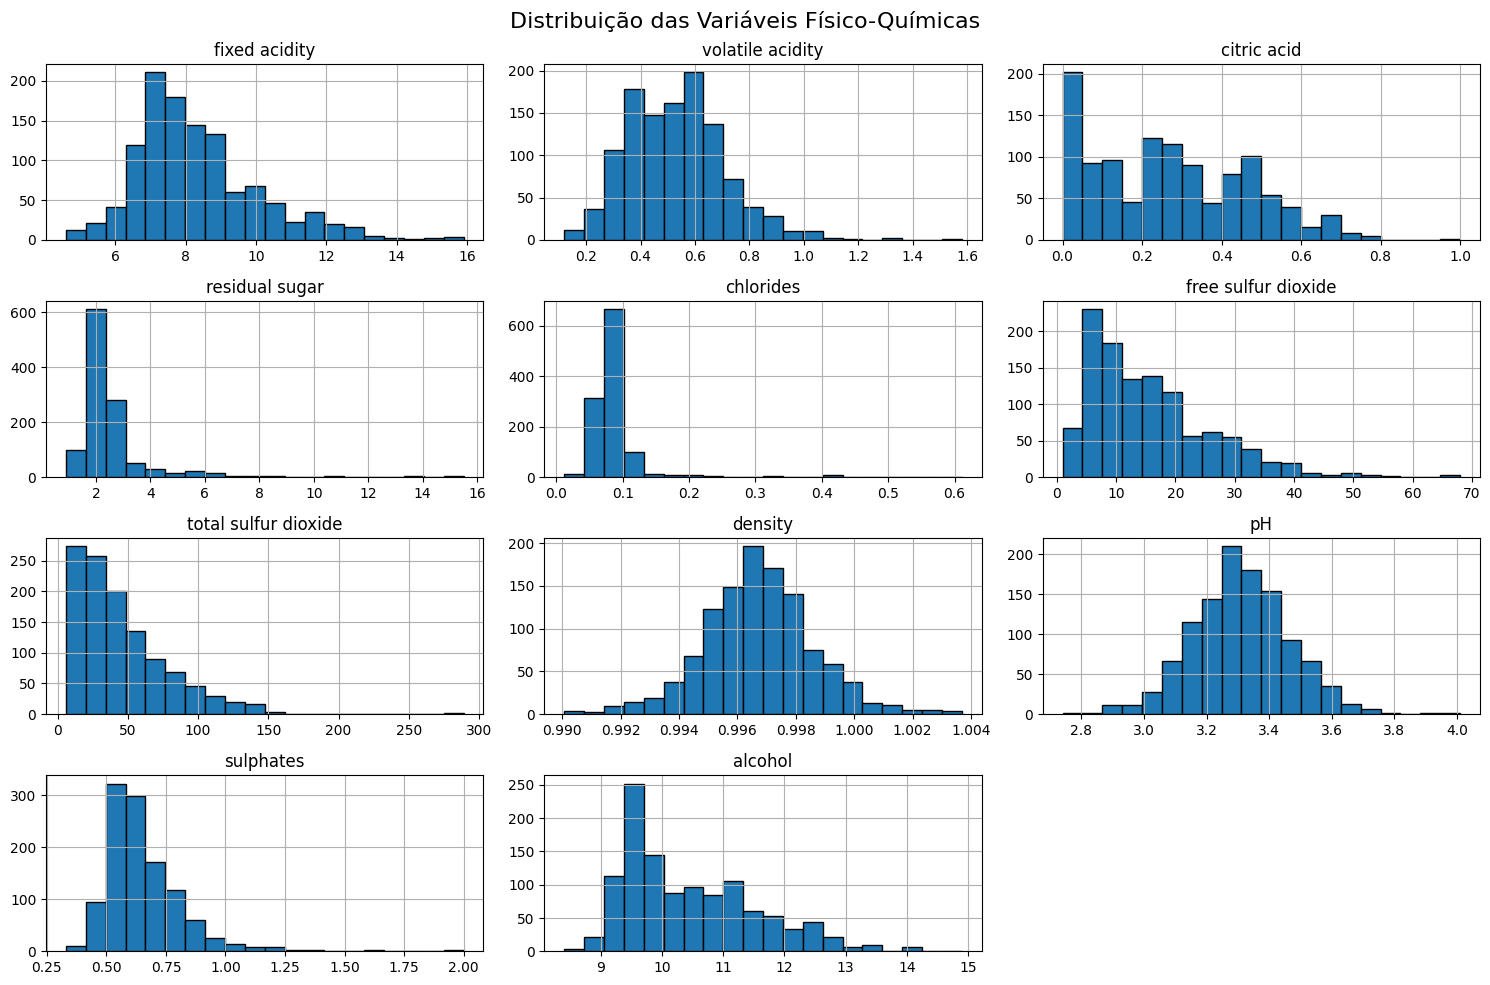

In [50]:
# Distribuição das variáveis
import matplotlib.pyplot as plt

variaveis_quimicas = df.drop(
    columns=["Id", "quality", "target", "classe_qualidade"],
    errors="ignore"
)

variaveis_quimicas.hist(
    figsize=(15, 10),
    bins=20,
    edgecolor="black"
)

plt.suptitle(
    "Distribuição das Variáveis Físico-Químicas",
    fontsize=16
)

plt.tight_layout()

# Salva o gráfico na pasta results
plt.savefig(
    f"{RESULTS_DIR}/distribuicao_variaveis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

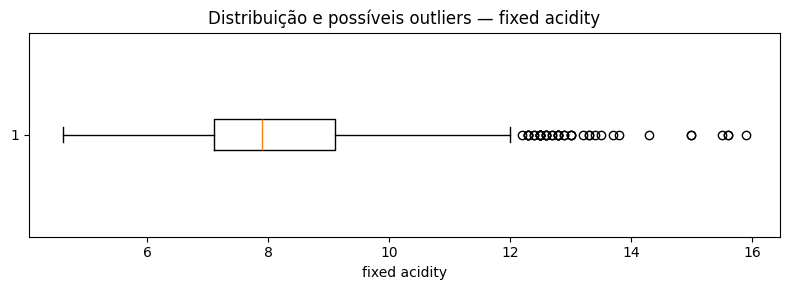

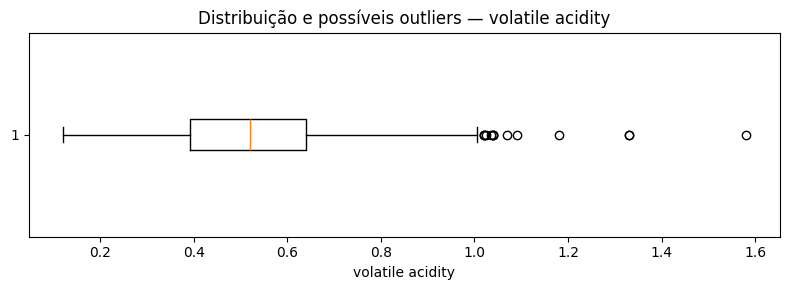

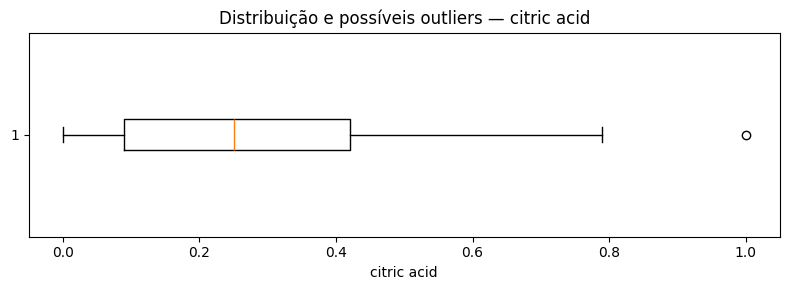

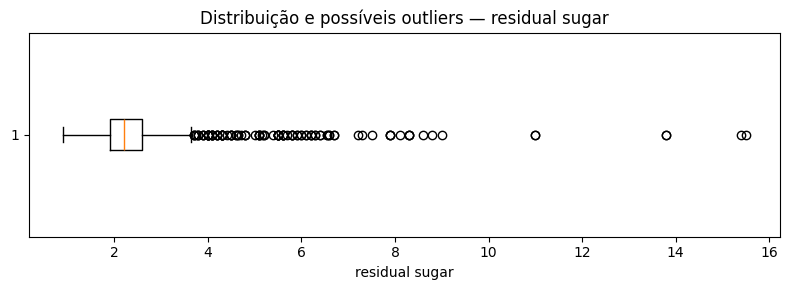

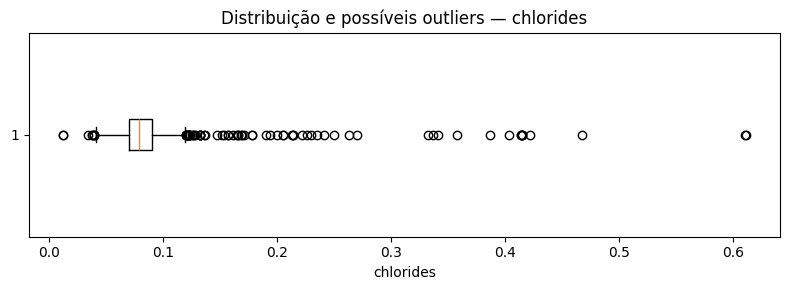

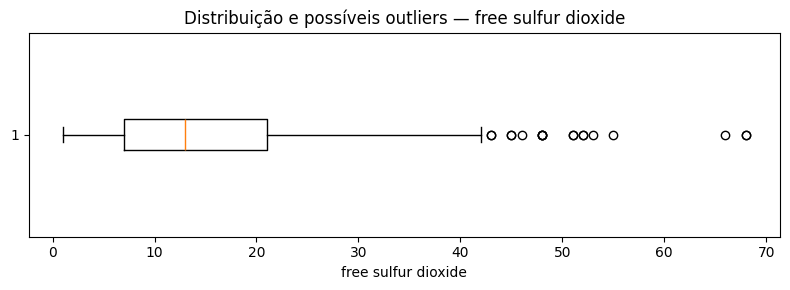

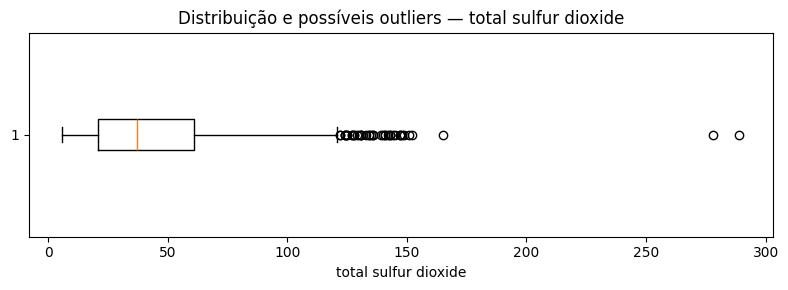

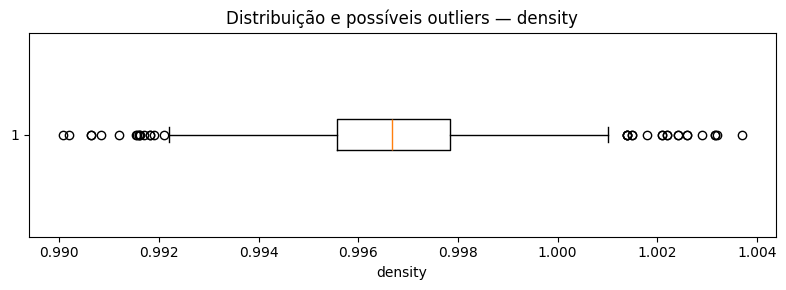

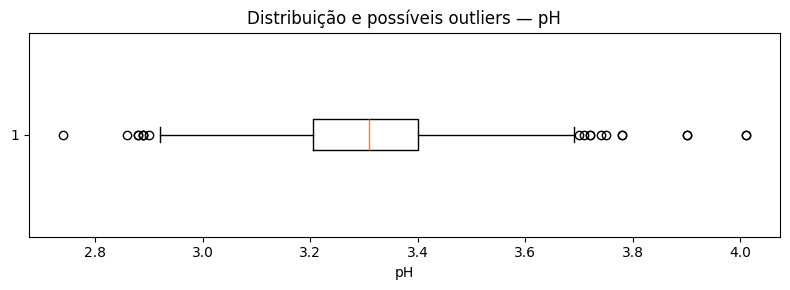

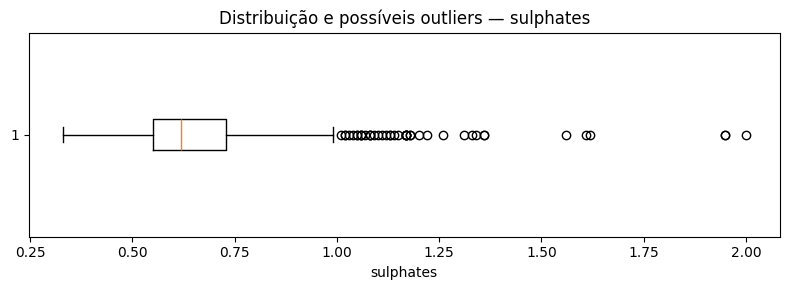

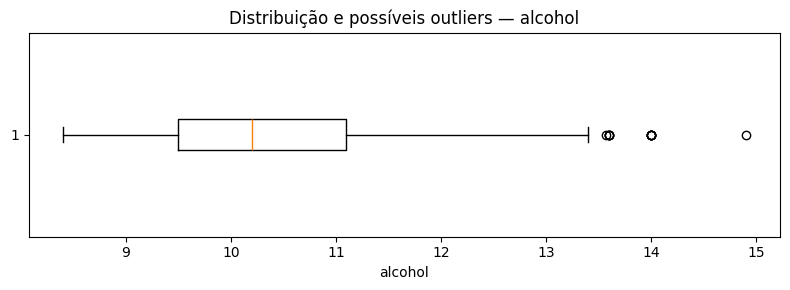

In [33]:
# Boxplots separados para identificação visual de outliers
for coluna in variaveis_quimicas.columns:
    plt.figure(figsize=(8, 3))

    plt.boxplot(
        variaveis_quimicas[coluna].dropna(),
        vert=False
    )

    plt.title(f"Distribuição e possíveis outliers — {coluna}")
    plt.xlabel(coluna)
    plt.tight_layout()
    plt.show()

In [52]:
# Quantificação de Outliers
resultados_outliers = []

for coluna in variaveis_quimicas.columns:
    Q1 = variaveis_quimicas[coluna].quantile(0.25)
    Q3 = variaveis_quimicas[coluna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    condicao_outlier = (
        (variaveis_quimicas[coluna] < limite_inferior) |
        (variaveis_quimicas[coluna] > limite_superior)
    )

    quantidade_outliers = condicao_outlier.sum()

    resultados_outliers.append({
        "Variável": coluna,
        "Quantidade de outliers": quantidade_outliers,
        "Percentual da base": round(
            quantidade_outliers / len(variaveis_quimicas) * 100,
            2
        ),
        "Limite inferior": round(limite_inferior, 4),
        "Limite superior": round(limite_superior, 4)
    })

tabela_outliers = pd.DataFrame(resultados_outliers)

tabela_outliers = tabela_outliers.sort_values(
    by="Quantidade de outliers",
    ascending=False
).reset_index(drop=True)

tabela_outliers

# Salva a tabela de outliers na pasta results
tabela_outliers.to_csv(
    f"{RESULTS_DIR}/tabela_outliers.csv",
    index=False,
    encoding="utf-8-sig"
)

### Interpretação dos outliers

Os valores identificados pelo método do intervalo interquartil são
estatisticamente extremos, mas não necessariamente incorretos.

Por esse motivo, os registros não foram removidos automaticamente. O objetivo
desta etapa foi identificar e documentar sua presença antes da modelagem.

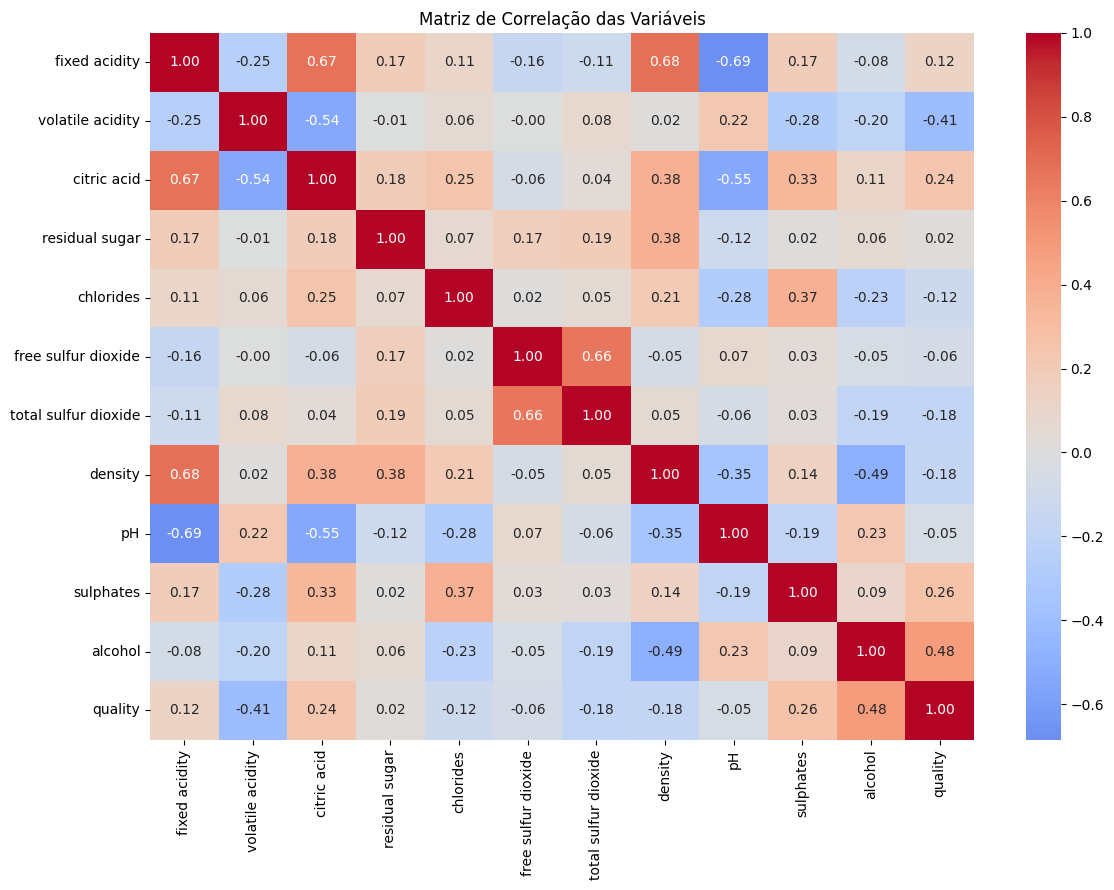

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apenas variáveis físico-químicas e a qualidade
dados_correlacao = df.drop(
    columns=["Id", "classe_qualidade", "target"],
    errors="ignore"
)

matriz_correlacao = dados_correlacao.corr(numeric_only=True)

plt.figure(figsize=(12, 9))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlação das Variáveis")
plt.tight_layout()

# Salva a matriz de correlação na pasta results
plt.savefig(
    f"{RESULTS_DIR}/matriz_correlacao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretação das correlações

O teor alcoólico apresentou a maior correlação positiva com a qualidade,
enquanto a acidez volátil apresentou a maior correlação negativa.

Também foram identificadas relações relevantes entre algumas características
físico-químicas, como álcool e densidade, acidez fixa e pH, além do dióxido de
enxofre livre e total.

Essas relações indicam que algumas variáveis carregam informações semelhantes
ou associadas. Correlação representa associação entre os dados e não comprova
uma relação de causa e efeito.

#7) Preparação e divisão dos dados

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Criar uma cópia da base para a modelagem
# Removemos Id e colunas auxiliares criadas anteriormente
df_modelo = df.drop(
    columns=["Id", "target", "classe_qualidade"],
    errors="ignore"
).copy()

# Remover registros repetidos considerando
# as características físico-químicas e a nota quality
df_modelo = df_modelo.drop_duplicates().reset_index(drop=True)

# Criar a variável alvo binária
# 1 = Alta Qualidade, nota maior ou igual a 7
# 0 = Baixa/Média Qualidade, nota menor que 7
df_modelo["target"] = (df_modelo["quality"] >= 7).astype(int)

# Mostrar o resultado da limpeza
print(f"Registros antes da remoção das duplicatas: {len(df)}")
print(f"Registros após a remoção das duplicatas: {len(df_modelo)}")
print(f"Registros removidos: {len(df) - len(df_modelo)}")

# Verificar o balanceamento das classes
# na base utilizada para a modelagem
balanceamento_modelagem = (
    df_modelo["target"]
    .value_counts()
    .rename(index={
        0: "Baixa/Média Qualidade",
        1: "Alta Qualidade"
    })
    .to_frame("Quantidade")
)

balanceamento_modelagem["Percentual"] = (
    balanceamento_modelagem["Quantidade"] /
    len(df_modelo) * 100
).round(1)

print("\nBalanceamento da base utilizada para modelagem:")
display(balanceamento_modelagem)

# Separar variáveis explicativas e variável alvo
X = df_modelo.drop(columns=["quality", "target"])
y = df_modelo["target"]

# Dividir a base:
# 80% para treinamento e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Padronização para uso na Regressão Logística
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nRegistros de treinamento: {len(X_train)}")
print(f"Registros de teste: {len(X_test)}")

print("\nProporção das classes no treinamento:")
print(
    y_train
    .value_counts(normalize=True)
    .sort_index()
    .rename(index={
        0: "Baixa/Média Qualidade",
        1: "Alta Qualidade"
    })
    .round(3)
)

print("\nProporção das classes no teste:")
print(
    y_test
    .value_counts(normalize=True)
    .sort_index()
    .rename(index={
        0: "Baixa/Média Qualidade",
        1: "Alta Qualidade"
    })
    .round(3)
)

Registros antes da remoção das duplicatas: 1143
Registros após a remoção das duplicatas: 1018
Registros removidos: 125

Balanceamento da base utilizada para modelagem:


,Quantidade,Percentual
target,,
Baixa/Média Qualidade,881,86.5
Alta Qualidade,137,13.5



Registros de treinamento: 814
Registros de teste: 204

Proporção das classes no treinamento:
target
Baixa/Média Qualidade    0.865
Alta Qualidade           0.135
Name: proportion, dtype: float64

Proporção das classes no teste:
target
Baixa/Média Qualidade    0.868
Alta Qualidade           0.132
Name: proportion, dtype: float64


# 8) Treinamento dos modelos

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Regressão Logística
# Utiliza os dados padronizados
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# Random Forest
# Utiliza os dados sem padronização
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Modelos treinados com sucesso!")

Modelos treinados com sucesso!


#9) Comparação de desempenho

In [38]:
from sklearn.metrics import classification_report

# Avaliando as métricas de acerto
print("--- DESEMPENHO: REGRESSÃO LOGÍSTICA ---")
print(classification_report(y_test, lr_pred))

print("\n--- DESEMPENHO: RANDOM FOREST ---")
print(classification_report(y_test, rf_pred))

--- DESEMPENHO: REGRESSÃO LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       177
           1       0.65      0.48      0.55        27

    accuracy                           0.90       204
   macro avg       0.79      0.72      0.75       204
weighted avg       0.89      0.90      0.89       204


--- DESEMPENHO: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       177
           1       0.72      0.48      0.58        27

    accuracy                           0.91       204
   macro avg       0.82      0.73      0.76       204
weighted avg       0.90      0.91      0.90       204



In [39]:
#tabela resumida
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparacao_modelos = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Random Forest"
    ],
    "Acurácia": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precisão - Alta Qualidade": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall - Alta Qualidade": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1-score - Alta Qualidade": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparacao_modelos.iloc[:, 1:] = comparacao_modelos.iloc[:, 1:].round(3)

comparacao_modelos

,Modelo,Acurácia,Precisão - Alta Qualidade,Recall - Alta Qualidade,F1-score - Alta Qualidade
0,Regressão Logística,0.897,0.650,0.481,0.553
1,Random Forest,0.907,0.722,0.481,0.578


#10) Experimento adicional — Tratamento do desbalanceamento

Como a classe de alta qualidade representa uma parcela menor da base,
foram testadas versões dos modelos com pesos balanceados.

O objetivo é verificar se o ajuste melhora a identificação dos vinhos de
alta qualidade, representada pelo recall da classe 1.

In [40]:
# treinar modelos balanceados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Regressão Logística com tratamento do desbalanceamento
lr_balanced = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

lr_balanced.fit(X_train_scaled, y_train)
lr_balanced_pred = lr_balanced.predict(X_test_scaled)

# Random Forest com tratamento do desbalanceamento
rf_balanced = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf_balanced.fit(X_train, y_train)
rf_balanced_pred = rf_balanced.predict(X_test)

print("Modelos balanceados treinados com sucesso!")

Modelos balanceados treinados com sucesso!


In [41]:
# Relatórios dos modelos balanceados
from sklearn.metrics import classification_report

print("--- REGRESSÃO LOGÍSTICA BALANCEADA ---")
print(classification_report(y_test, lr_balanced_pred))

print("\n--- RANDOM FOREST BALANCEADO ---")
print(classification_report(y_test, rf_balanced_pred))

--- REGRESSÃO LOGÍSTICA BALANCEADA ---
              precision    recall  f1-score   support

           0       0.96      0.79      0.86       177
           1       0.36      0.78      0.49        27

    accuracy                           0.78       204
   macro avg       0.66      0.78      0.68       204
weighted avg       0.88      0.78      0.81       204


--- RANDOM FOREST BALANCEADO ---
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       177
           1       0.90      0.33      0.49        27

    accuracy                           0.91       204
   macro avg       0.90      0.66      0.72       204
weighted avg       0.91      0.91      0.89       204



In [53]:
# Comparar as quatro versões
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

comparacao_experimento = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Random Forest",
        "Regressão Logística Balanceada",
        "Random Forest Balanceado"
    ],

    "Acurácia": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, lr_balanced_pred),
        accuracy_score(y_test, rf_balanced_pred)
    ],

    "Precisão - Alta Qualidade": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, lr_balanced_pred),
        precision_score(y_test, rf_balanced_pred)
    ],

    "Recall - Alta Qualidade": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, lr_balanced_pred),
        recall_score(y_test, rf_balanced_pred)
    ],

    "F1-score - Alta Qualidade": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, lr_balanced_pred),
        f1_score(y_test, rf_balanced_pred)
    ]
})

comparacao_experimento.iloc[:, 1:] = (
    comparacao_experimento.iloc[:, 1:].round(3)
)

display(comparacao_experimento)

# Salva a comparação completa dos modelos
comparacao_experimento.to_csv(
    f"{RESULTS_DIR}/comparacao_modelos.csv",
    index=False,
    encoding="utf-8-sig"
)

,Modelo,Acurácia,Precisão - Alta Qualidade,Recall - Alta Qualidade,F1-score - Alta Qualidade
0,Regressão Logística,0.897,0.650,0.481,0.553
1,Random Forest,0.907,0.722,0.481,0.578
2,Regressão Logística Balanceada,0.784,0.356,0.778,0.488
3,Random Forest Balanceado,0.907,0.900,0.333,0.486


### Conclusão do experimento

O tratamento do desbalanceamento produziu efeitos diferentes nos modelos.

Na Regressão Logística, o recall da classe de alta qualidade aumentou de
48,1% para 77,8%. Isso significa que o modelo passou a identificar uma parcela
maior dos vinhos realmente classificados como alta qualidade. Entretanto, esse
ganho ocorreu com redução da acurácia, da precisão e do F1-score.

No Random Forest, a aplicação de pesos balanceados não trouxe melhoria. O
recall da classe de alta qualidade caiu de 48,1% para 33,3%.

Considerando o equilíbrio entre acurácia, precisão, recall e F1-score, o
Random Forest sem balanceamento permaneceu como o melhor modelo geral.

Caso a prioridade do negócio seja identificar o maior número possível de
vinhos potencialmente classificados como alta qualidade, a Regressão Logística
balanceada pode ser considerada, sabendo que ela gera mais falsos positivos.

#11) Feature Importance

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extrair a importância das variáveis no Random Forest
importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    "Variável": X.columns,
    "Importância": importances
}).sort_values(
    by="Importância",
    ascending=False
).reset_index(drop=True)

# Mostrar os valores exatos
feat_imp

,Variável,Importância
0,alcohol,0.159262
1,volatile acidity,0.118462
2,sulphates,0.114548
3,density,0.105778
4,citric acid,0.093094
5,fixed acidity,0.074629
6,chlorides,0.074447
7,total sulfur dioxide,0.071262
8,residual sugar,0.069211
9,pH,0.061815


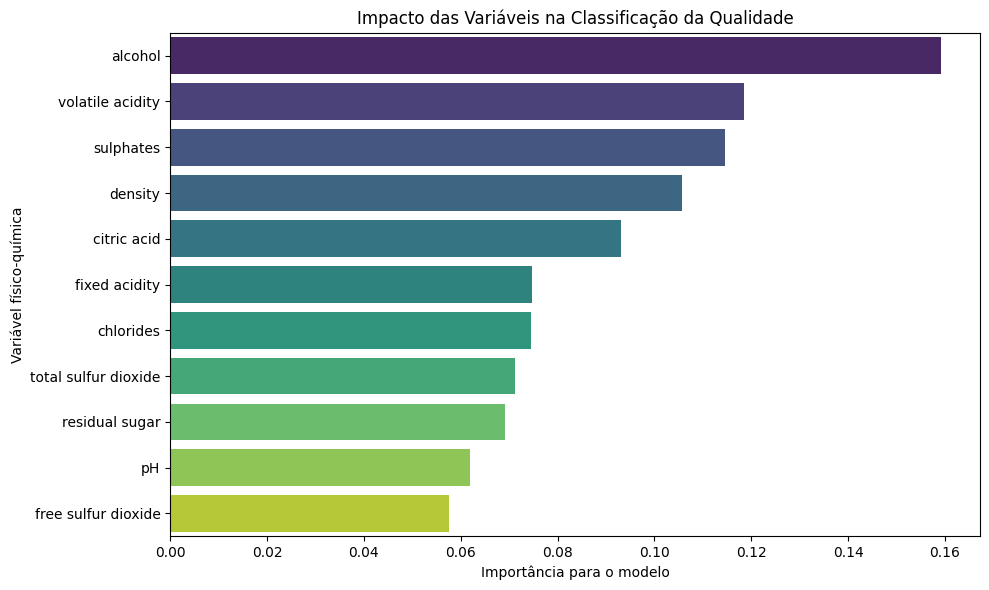

In [54]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feat_imp,
    x="Importância",
    y="Variável",
    hue="Variável",
    legend=False,
    palette="viridis"
)

plt.title("Impacto das Variáveis na Classificação da Qualidade")
plt.xlabel("Importância para o modelo")
plt.ylabel("Variável físico-química")

plt.tight_layout()

# Salva o gráfico de importância das variáveis
plt.savefig(
    f"{RESULTS_DIR}/importancia_variaveis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretação

O gráfico mostra quanto cada variável contribuiu para as decisões do modelo
Random Forest. Uma importância maior indica que a variável foi mais utilizada
pelo modelo para diferenciar vinhos de alta qualidade dos demais.

A importância das variáveis não deve ser interpretada como relação de causa
e efeito.

#12) Conclusão Técnica e Implicações para o Negócio

Entre os modelos avaliados, o **Random Forest sem balanceamento** apresentou o
melhor equilíbrio geral de desempenho, alcançando **90,7% de acurácia**,
**72,2% de precisão** e **57,8% de F1-score** para a classe de alta qualidade.

Apesar do bom desempenho geral, o modelo apresentou **recall de 48,1%** para
os vinhos de alta qualidade. Isso significa que ele identificou corretamente
menos da metade dos vinhos pertencentes a essa classe, evidenciando uma
oportunidade de aprimoramento na detecção dos casos positivos.

Como experimento adicional, também foram testadas versões dos modelos com
pesos balanceados. Na **Regressão Logística balanceada**, o recall da classe de
alta qualidade aumentou de **48,1% para 77,8%**, permitindo identificar uma
parcela maior dos vinhos realmente classificados como alta qualidade. No
entanto, esse ganho foi acompanhado por redução da acurácia, da precisão e do
F1-score, além do aumento de classificações incorretas de vinhos de
baixa/média qualidade como alta qualidade.

No **Random Forest balanceado**, não houve melhoria na identificação da classe
de alta qualidade, pois o recall caiu para **33,3%**. Por esse motivo, o
Random Forest sem balanceamento foi mantido como o modelo com melhor
desempenho geral.

A escolha final do modelo deve considerar a prioridade do negócio. Caso o
objetivo seja obter maior equilíbrio entre os diferentes tipos de acerto e
erro, o Random Forest sem balanceamento é a alternativa mais adequada. Caso a
prioridade seja reduzir a quantidade de vinhos de alta qualidade não
identificados, a Regressão Logística balanceada pode ser considerada, mesmo
com o aumento de falsos positivos.

No Random Forest selecionado, as variáveis que mais contribuíram para as
decisões do modelo foram **teor alcoólico, acidez volátil, sulfatos, densidade
e ácido cítrico**. Esses resultados indicam que o acompanhamento dessas
características físico-químicas pode apoiar produtores e especialistas na
avaliação e na padronização da qualidade dos vinhos.

Entretanto, a importância atribuída pelo modelo representa uma associação
encontrada nos dados e não comprova uma relação de causa e efeito. Portanto,
os resultados devem ser utilizados como apoio à tomada de decisão, em conjunto
com o conhecimento de enólogos e especialistas, e não como substituição da
avaliação técnica e sensorial.

In [45]:
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import sklearn

print(f"pandas=={pd.__version__}")
print(f"numpy=={np.__version__}")
print(f"matplotlib=={matplotlib.__version__}")
print(f"seaborn=={sns.__version__}")
print(f"scikit-learn=={sklearn.__version__}")

pandas==2.2.2
numpy==2.0.2
matplotlib==3.10.0
seaborn==0.13.2
scikit-learn==1.6.1
